<a href="https://colab.research.google.com/github/dibraheem225-crypto/hate-speech/blob/main/teethclassifiaion1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Teeth DataSet.zip to Teeth DataSet.zip


In [ ]:
import os

for root, dirs, files in os.walk('./Teeth_Dataset'):
    print(root)

In [ ]:
import zipfile

local_zip = './Teeth DataSet.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('./Teeth_Dataset')
zip_ref.close()

In [ ]:
import os
train_dir =  './Teeth_Dataset/Teeth_Dataset/Training'
validation_dir = './Teeth_Dataset/Teeth_Dataset/Validation'
test_dir = './Teeth_Dataset/Teeth_Dataset/Testing'

In [ ]:
train_classes = sorted([
    folder for folder in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, folder))
])

validation_classes = sorted([
    folder for folder in os.listdir(validation_dir)
    if os.path.isdir(os.path.join(validation_dir, folder))
])

test_classes = sorted([
    folder for folder in os.listdir(test_dir)
    if os.path.isdir(os.path.join(test_dir, folder))
])

print("Training Classes:", train_classes)
print("Validation Classes:", validation_classes)
print("Testing Classes:", test_classes)

print("\nNumber of classes:", len(train_classes))

Training Classes: ['CaS', 'CoS', 'Gum', 'MC', 'OC', 'OLP', 'OT']
Validation Classes: ['CaS', 'CoS', 'Gum', 'MC', 'OC', 'OLP', 'OT']
Testing Classes: ['CaS', 'CoS', 'Gum', 'MC', 'OC', 'OLP', 'OT']

Number of classes: 7


In [ ]:
import os

train_images = sum(len(files) for _, _, files in os.walk(train_dir))
validation_images = sum(len(files) for _, _, files in os.walk(validation_dir))
test_images = sum(len(files) for _, _, files in os.walk(test_dir))

print(f'Total training images: {train_images}')
print(f'Total validation images: {validation_images}')
print(f'Total testing images: {test_images}')

Total training images: 3087
Total validation images: 1028
Total testing images: 1028


In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

import matplotlib.image as mpimg

# Parameters for our graph; we'll output images in a 4x4 configuration
nrows= 4
ncols = 4
# Index for iterating over images
pic_index=0

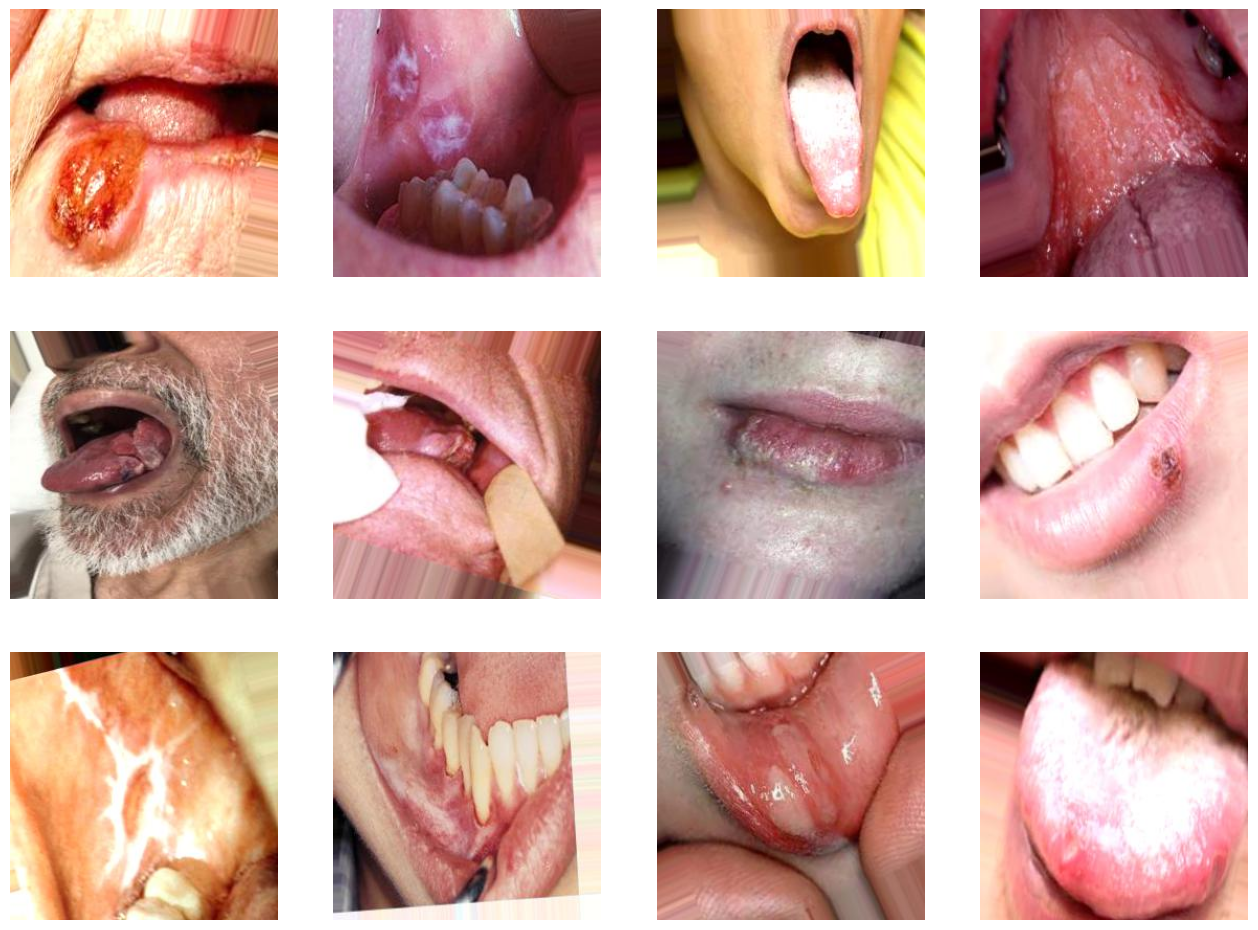

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig = plt.gcf()
fig.set_size_inches(ncols * 4, nrows * 4)

pic_index += 8

classes = ['MC', 'OT', 'OC', 'CoS', 'OLP', 'CaS', 'Gum']

next_teeth_pix = []

for cls in classes:
    class_dir = os.path.join(train_dir, cls)
    images = os.listdir(class_dir)

    for img in images[:2]:
        next_teeth_pix.append(os.path.join(class_dir, img))


for i, img_path in enumerate(next_teeth_pix[:12]):

    sp = plt.subplot(nrows, ncols, i + 1)
    sp.axis('off')

    img = mpimg.imread(img_path)
    plt.imshow(img)

plt.show()

In [ ]:
IMG_SIZE = (300, 300)
BATCH_SIZE = 128

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)


validation_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)
validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)
print(train_generator.class_indices)

Found 3087 images belonging to 7 classes.
Found 1028 images belonging to 7 classes.
Found 1028 images belonging to 7 classes.
{'CaS': 0, 'CoS': 1, 'Gum': 2, 'MC': 3, 'OC': 4, 'OLP': 5, 'OT': 6}


In [ ]:
# Calculate steps per epoch
steps_per_epoch = train_images // BATCH_SIZE
validation_steps = validation_images // BATCH_SIZE

print(f"Steps per epoch for training: {steps_per_epoch}")
print(f"Steps per epoch for validation: {validation_steps}")

Steps per epoch for training: 96
Steps per epoch for validation: 32


In [ ]:
import tensorflow as tf
from tensorflow.keras import models, layers

model =models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(300, 300, 3)),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),


    layers.Conv2D (128, (3, 3),activation='relu'),

    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),

    layers.Dense(7, activation='softmax')
])
model.compile(
    optimizer='RMSprop',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 298, 298, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 149, 149, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 147, 147, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 73, 73, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 71, 71, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 35, 35, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 156800)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │    20,070,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,164,679 (76.92 MB)

 Trainable params: 20,164,679 (76.92 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.optimizers import RMSprop
model.compile(loss='categorical_crossentropy',

optimizer=RMSprop(learning_rate=0.001),

metrics=['accuracy'])

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1/255,
    rotation_range=0.2
)
validation_datagen = ImageDataGenerator (rescale=1/255)

train_generator = train_datagen.flow_from_directory(

train_dir,
target_size=IMG_SIZE,
batch_size=BATCH_SIZE,
class_mode='categorical')
validation_generator = validation_datagen.flow_from_directory(
validation_dir,
target_size=IMG_SIZE,
batch_size=BATCH_SIZE,
class_mode='categorical')

Found 3087 images belonging to 7 classes.
Found 1028 images belonging to 7 classes.


In [ ]:
history = model.fit(
    train_generator,
    epochs=15,
    verbose=1,
    validation_data=validation_generator,

)
test_datagen = ImageDataGenerator(
    rescale=1./255
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 751s 30s/step - accuracy: 0.2883 - loss: 1.8124 - val_accuracy: 0.3755 - val_loss: 1.6866
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 674s 27s/step - accuracy: 0.3473 - loss: 1.7273 - val_accuracy: 0.3716 - val_loss: 1.6129
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 703s 28s/step - accuracy: 0.3991 - loss: 1.6143 - val_accuracy: 0.3473 - val_loss: 1.6319
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 673s 27s/step - accuracy: 0.4772 - loss: 1.4229 - val_accuracy: 0.4105 - val_loss: 1.5997
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 673s 27s/step - accuracy: 0.5332 - loss: 1.3388 - val_accuracy: 0.4698 - val_loss: 1.4121
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 669s 27s/step - accuracy: 0.6152 - loss: 1.1033 - val_accuracy: 0.4387 - val_loss: 1.5377
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 698s 28s/step - accuracy: 0.6741 - loss: 0.9306 - val_accuracy: 0.4825 - val_loss: 1.4259
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 694s 27s/step - accuracy: 0.7551 - loss: 0.7501 - val_accuracy: 0.

In [ ]:
import numpy as np
from google.colab import files
from tensorflow.keras.utils import load_img, img_to_array

uploaded = files.upload()

for fn in uploaded.keys():
    path = '/content/' + fn

    img = load_img(
        path,
        target_size=(300, 300)
    )

    x = img_to_array(img)
    x /= 255.0
    x = np.expand_dims(x, axis=0)
    classes = model.predict(x)
    print("Prediction probabilities:")
    print(classes[0])
    predicted_class = np.argmax(classes[0])
    class_names = list(train_generator.class_indices.keys())
    print("Predicted class:", class_names[predicted_class])


Saving a_81_0_9451.jpg to a_81_0_9451.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step
Prediction probabilities:
[3.2243896e-01 5.2307266e-01 1.5214812e-06 1.0456225e-03 2.1668116e-04
 8.2758479e-03 1.4494871e-01]
Predicted class: CoS


In [ ]:
import tensorflow as tf

model2 = tf.keras.models.Sequential([

    tf.keras.layers.Conv2D(16, (3, 3),activation="relu",input_shape=(300, 300, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(32, (3, 3),activation="relu"),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(64, (3, 3),activation="relu"),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(64, (3, 3),activation="relu"),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(64, (3, 3),activation="relu"),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(512,activation="relu" ),

    tf.keras.layers.Dense(7,activation="softmax")
])


In [ ]:
model2.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_33 (Conv2D)              │ (None, 298, 298, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 149, 149, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 147, 147, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 73, 73, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 71, 71, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 35, 35, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 33, 33, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 512)            │     1,606,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,175 (6.51 MB)

 Trainable params: 1,707,175 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.optimizers import RMSprop
model2.compile(loss='categorical_crossentropy',

optimizer=RMSprop(learning_rate=0.001),

metrics=['accuracy'])

In [ ]:
history = model2.fit(
    train_generator,
    epochs=15,
    verbose=1,
    validation_data=validation_generator,

)
test_datagen = ImageDataGenerator(
    rescale=1./255
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 368s 14s/step - accuracy: 0.1759 - loss: 1.9767 - val_accuracy: 0.1887 - val_loss: 1.9302
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 356s 14s/step - accuracy: 0.1995 - loss: 1.9205 - val_accuracy: 0.2879 - val_loss: 1.8503
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 372s 15s/step - accuracy: 0.2527 - loss: 1.8769 - val_accuracy: 0.2986 - val_loss: 1.7888
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 359s 14s/step - accuracy: 0.2954 - loss: 1.8034 - val_accuracy: 0.2860 - val_loss: 1.7827
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 358s 14s/step - accuracy: 0.3547 - loss: 1.7168 - val_accuracy: 0.2393 - val_loss: 1.9453
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 360s 14s/step - accuracy: 0.3826 - loss: 1.6203 - val_accuracy: 0.4358 - val_loss: 1.5328
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 411s 15s/step - accuracy: 0.4542 - loss: 1.4916 - val_accuracy: 0.3706 - val_loss: 1.6544
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 368s 15s/step - accuracy: 0.4901 - loss: 1.3845 - val_accuracy: 0.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    height_shift_range=0.2,
    width_shift_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=40,
    shear_range=0.1,
    zoom_range=0.3,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)
test_datagen = ImageDataGenerator(
    rescale=1./255
)
train_generator = train_datagen.flow_from_directory(
    '/content/Teeth_Dataset/Teeth_Dataset/Training',
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)
validation_generator = val_datagen.flow_from_directory(
    '/content/Teeth_Dataset/Teeth_Dataset/Validation',
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)
test_generator = test_datagen.flow_from_directory(
    '/content/Teeth_Dataset/Teeth_Dataset/Testing',
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 3087 images belonging to 7 classes.
Found 1028 images belonging to 7 classes.
Found 1028 images belonging to 7 classes.


In [ ]:
from tensorflow.keras.applications.inception_v3 import InceptionV3
pre_trained_model = InceptionV3(
weights='imagenet',
include_top=False,
input_shape=(150, 150, 3)
)
for layer in pre_trained_model.layers:
    layer.trainable = False
pre_trained_model.summary()

Model: "inception_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_15      │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_226 (Conv2D) │ (None, 74, 74,    │        864 │ input_layer_15[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 74, 74,    │         96 │ conv2d_226[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_188      │ (None, 74, 74,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_227 (Conv2D) │ (None, 72, 72,    │      9,216 │ activation_188[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 72, 72,    │         96 │ conv2d_227[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_189      │ (None, 72, 72,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_228 (Conv2D) │ (None, 72, 72,    │     18,432 │ activation_189[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 72, 72,    │        192 │ conv2d_228[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_190      │ (None, 72, 72,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_46    │ (None, 35, 35,    │          0 │ activation_190[0… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_229 (Conv2D) │ (None, 35, 35,    │      5,120 │ max_pooling2d_46… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 35, 35,    │        240 │ conv2d_229[0][0]  │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_191      │ (None, 35, 35,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_230 (Conv2D) │ (None, 33, 33,    │    138,240 │ activation_191[0… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 33, 33,    │        576 │ conv2d_230[0][0]  │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_192      │ (None, 33, 33,    │          0 │ batch_normalizat

 Total params: 21,802,784 (83.17 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 21,802,784 (83.17 MB)

In [ ]:
last_layer = pre_trained_model.get_layer('mixed7')
last_output = last_layer.output

In [ ]:
import tensorflow as tf
class myCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs={}):
    if(logs.get('accuracy')>0.99):
       print("\nReached 99.0% accuracy so cancelling training!")
       self.model.stop_training = True

In [ ]:
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras import layers, Model

flatten = layers.Flatten()(last_output)
dense1 = layers.Dense(1024, activation='relu')(flatten)
drop = layers.Dropout(0.2)(dense1)
output = layers.Dense(7, activation='softmax')(drop)
model = Model(pre_trained_model.input, outputs=output)
model.compile(optimizer = RMSprop(),
loss='categorical_crossentropy',
metrics=['accuracy'])
model.summary()

Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_15      │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_226 (Conv2D) │ (None, 74, 74,    │        864 │ input_layer_15[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 74, 74,    │         96 │ conv2d_226[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_188      │ (None, 74, 74,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_227 (Conv2D) │ (None, 72, 72,    │      9,216 │ activation_188[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 72, 72,    │         96 │ conv2d_227[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_189      │ (None, 72, 72,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_228 (Conv2D) │ (None, 72, 72,    │     18,432 │ activation_189[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 72, 72,    │        192 │ conv2d_228[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_190      │ (None, 72, 72,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_46    │ (None, 35, 35,    │          0 │ activation_190[0… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_229 (Conv2D) │ (None, 35, 35,    │      5,120 │ max_pooling2d_46… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 35, 35,    │        240 │ conv2d_229[0][0]  │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_191      │ (None, 35, 35,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_230 (Conv2D) │ (None, 33, 33,    │    138,240 │ activation_191[0… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 33, 33,    │        576 │ conv2d_230[0][0]  │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_192      │ (None, 33, 33,    │          0 │ batch_normalizat

 Total params: 47,518,631 (181.27 MB)

 Trainable params: 38,543,367 (147.03 MB)

 Non-trainable params: 8,975,264 (34.24 MB)

In [ ]:
callbacks = myCallback()
history = model.fit(train_generator,
epochs = 30,
validation_data = validation_generator,
verbose = 1,
callbacks = [callbacks])

Epoch 1/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 238s 2s/step - accuracy: 0.3994 - loss: 3.3921 - val_accuracy: 0.5953 - val_loss: 1.1348
Epoch 2/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 236s 2s/step - accuracy: 0.5594 - loss: 1.2055 - val_accuracy: 0.6955 - val_loss: 0.8577
Epoch 3/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 223s 2s/step - accuracy: 0.6187 - loss: 1.0316 - val_accuracy: 0.7091 - val_loss: 0.7879
Epoch 4/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 225s 2s/step - accuracy: 0.6683 - loss: 0.9298 - val_accuracy: 0.7724 - val_loss: 0.6391
Epoch 5/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 226s 2s/step - accuracy: 0.6919 - loss: 0.8272 - val_accuracy: 0.8123 - val_loss: 0.5444
Epoch 6/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 229s 2s/step - accuracy: 0.7130 - loss: 0.7785 - val_accuracy: 0.8268 - val_loss: 0.5140
Epoch 7/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 226s 2s/step - accuracy: 0.7127 - loss: 0.7744 - val_accuracy: 0.8444 - val_loss: 0.4559
Epoch 8/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 226s 2s/step - accuracy: 0.7554 - loss: 0.6965 - val_accuracy: 0.8726 - v

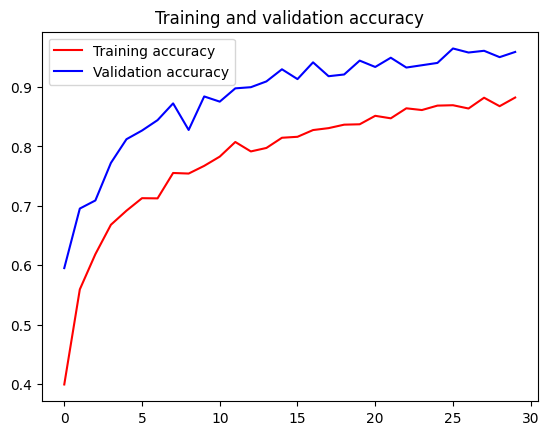

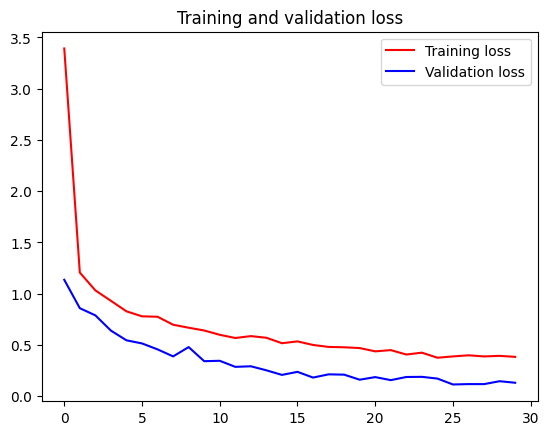

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(acc))
plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend(loc=0)
plt.figure()
plt.plot(epochs, loss, 'r', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend(loc=0)
plt.show()